# Arne report for the all cycles 

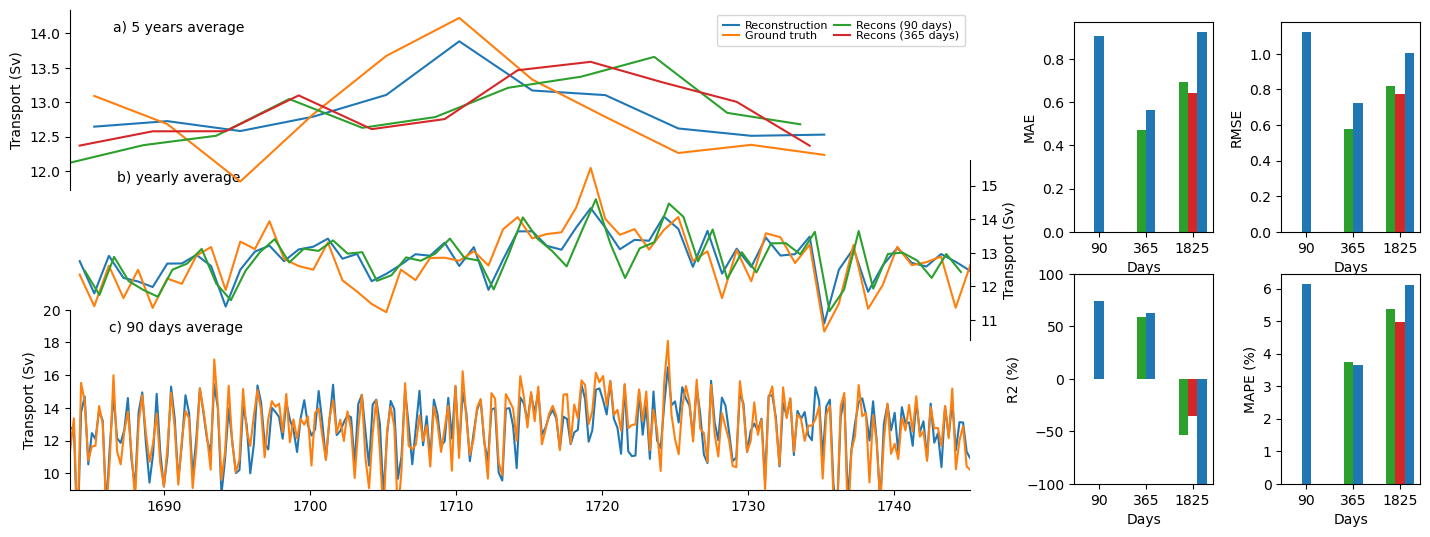

In [10]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt


import numpy as np
backward_shift = np.array(5396198400000000000, dtype='timedelta64[ns]')

experiment_path = Path('../rapid-geostrophic-reconstruction/figs/')

## Train on all six predict sixth cycle 
experiment_90d = 'experiment_20250228_082444'
experiment_365d = 'experiment_20250228_082319'
experiment_1825d = 'experiment_20250228_082731'

experiment_90d_2c = None
experiment_365d_2c = None

## Train on all six predict third cycle 
# experiment_90d = 'experiment_20250227_220148'
# experiment_365d = 'experiment_20250227_172909'#'experiment_20250225_172718'
# experiment_1825d = 'experiment_20250227_215443'

# experiment_90d_2c = None
# experiment_365d_2c = None


## Train on all six predict the 2005 to 2025 period
# experiment_90d = 'experiment_20250227_215148'
# experiment_365d = 'experiment_20250227_180137' # 'experiment_20250226_151312'
# experiment_1825d = 'experiment_20250227_215242'

# experiment_90d_2c = 'experiment_20250228_065334'
# experiment_365d_2c = 'experiment_20250228_074151'



test_predictions_90d = xr.open_dataset(experiment_path / experiment_90d / 'ensemble_predictions.nc').mean('member')
test_predictions_365d = xr.open_dataset(experiment_path / experiment_365d / 'ensemble_predictions.nc').mean('member')
test_predictions_1825d = xr.open_dataset(experiment_path / experiment_1825d / 'ensemble_predictions.nc').mean('member')

test_predictions_90d['time'] = test_predictions_90d.time + np.array(5372438400000000000, dtype='timedelta64[ns]')
test_predictions_365d['time'] = test_predictions_365d.time + np.array(5396198400000000000, dtype='timedelta64[ns]')
test_predictions_1825d['time'] = test_predictions_1825d.time + np.array(5522342400000000000, dtype='timedelta64[ns]')
axes_width = .6

fig = plt.figure(figsize=(15, 6))
from matplotlib.gridspec import GridSpec
gs = GridSpec(2,3, figure=fig, width_ratios=[.7,.13,.13])
ax = fig.add_axes([0, 0.1, axes_width, .3])

if experiment_90d_2c is not None:
    test_predictions_90d_2c = xr.open_dataset(experiment_path / experiment_90d_2c / 'ensemble_predictions.nc').mean('member')
    ax.plot(test_predictions_90d.time, test_predictions_90d_2c.test_predictions, label = 'Reconstruction (2 cycle)', color = 'k', linestyle = '--')
ax.plot(test_predictions_90d.time, test_predictions_90d.test_predictions, label = 'Reconstruction')
ax.plot(test_predictions_90d.time, test_predictions_90d.test_gt_transport, label='Ground truth')

# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# ax.set_xticks([])

ax.set_ylim(9,20)

ax.text(0.12, 0.9, f'c) 90 days average ', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
ax.tick_params(labelbottom=True)

ax.set_ylabel('Transport (Sv)')
# ax.set_xlabel('Test cycle no. 3')
ax90 = ax

ax = fig.add_axes([0, 0.35, axes_width, .3])

smoothing_days = 365
# test_predictions_90d_365d = test_predictions_90d.resample(time=f'{smoothing_days}D').mean()
test_predictions_90d_365d = test_predictions_90d.resample(time = '1D').ffill().resample(time=f'{smoothing_days}D').mean().sel(time = test_predictions_365d.time, method='nearest')
if experiment_365d_2c is not None:
    test_predictions_365d_2c = xr.open_dataset(experiment_path / experiment_365d_2c / 'ensemble_predictions.nc').mean('member')
    ax.plot(test_predictions_365d_2c.time, test_predictions_365d_2c.test_predictions, label = 'Reconstruction (2 cycle)', color = 'k', linestyle = '--')
ax.plot(test_predictions_365d.time, test_predictions_365d.test_predictions, label = 'Reconstruction')
ax.plot(test_predictions_365d.time, test_predictions_365d.test_gt_transport, label='Ground truth')
ax.plot(test_predictions_90d_365d.time, test_predictions_90d_365d.test_predictions, label = 'Reconstruction (from 90 days)')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


ax.set_xticks([])
ax.text(0.12, 0.9, 'b) yearly average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

#set y axis on right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_facecolor('none')
ax.set_ylabel('Transport (Sv)')
# ax.set_ylim(11,15)
ax365 = ax

ax = fig.add_axes([0, 0.6, axes_width, .3])


smoothing_days = 1825
test_predictions_90d_1825d = test_predictions_90d.resample(time = '1D').ffill().resample(time=f'{smoothing_days}D').mean().sel(time = test_predictions_1825d.time, method='nearest')
test_predictions_365d_1825d = test_predictions_365d.resample(time = '1D').ffill().resample(time=f'{smoothing_days}D').mean().sel(time = test_predictions_1825d.time, method='nearest')
ax.plot(test_predictions_1825d.time, test_predictions_1825d.test_predictions, label = 'Reconstruction')
ax.plot(test_predictions_1825d.time, test_predictions_1825d.test_gt_transport, label='Ground truth')
ax.plot(test_predictions_90d_1825d.time, test_predictions_90d_1825d.test_predictions, label = 'Recons (90 days)')
ax.plot(test_predictions_365d_1825d.time, test_predictions_365d_1825d.test_predictions, label = 'Recons (365 days)')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.set_ylabel('Transport (Sv)')

#set background color to transparent
ax.set_facecolor('none')
ax.text(0.12, 0.9, 'a) 5 years average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
ax.legend(loc = 'upper right', fontsize = 8, ncol=2, labelspacing = .0, columnspacing = .5, handletextpad = .5, borderpad = .5, handlelength = 1.5, borderaxespad = .5)
# ax.set_ylim(11,15)
ax1825 = ax
# # fig.tight_layout()


# # plt.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300)

# # save complete figure

# # fig.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300)


# fig.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300, bbox_inches='tight')

min_time = min(
    test_predictions_90d.time.min(),
    test_predictions_365d.time.min(),
    test_predictions_1825d.time.min()

)

max_time = max(
    test_predictions_90d.time.max(),
    test_predictions_365d.time.max(),
    test_predictions_1825d.time.max()
)

ax90.set_xlim(min_time.values, max_time.values)
ax365.set_xlim(min_time.values, max_time.values)
ax1825.set_xlim(min_time.values, max_time.values)

ax = fig.add_subplot(gs[0,1])
width = .2
draw_skill_plot('MAE', width, ax)

ax = fig.add_subplot(gs[0,2])
draw_skill_plot('RMSE', width, ax)

ax = fig.add_subplot(gs[1,1])
draw_skill_plot('R2', width, ax)
ax.set_ylim(-100,100)

ax = fig.add_subplot(gs[1,2])
draw_skill_plot('MAPE', width, ax)

# fig.tight_layout()

plt.show()

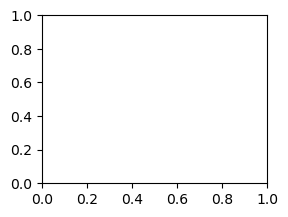

In [2]:
import json
fig = plt.figure()

ax = fig.add_subplot(2,2,1)

with open(experiment_path / experiment_90d / 'ensemble_metrics.json') as f:
    metrics_90d = json.load(f)

with open(experiment_path / experiment_365d / 'ensemble_metrics.json') as f:
    metrics_365d = json.load(f)


with open(experiment_path / experiment_1825d / 'ensemble_metrics.json') as f:
    metrics_1825d = json.load(f)

width = .2

def draw_skill_plot(skill, width, ax):

    factor = 1
    if skill in ['R2', 'MAPE']:
        factor = 100


    ax.bar(
        [1,2+(width/2),3+width],
        [
            metrics_90d['original']['mean'][skill]* factor,
            metrics_365d['original']['mean'][skill]* factor,
            metrics_1825d['original']['mean'][skill]* factor,
        ], 
        width=width
    )

    ax.bar(
        [1],
        [
        0
        ],
    )


    ax.bar(
        [2-(width / 2),3- width],
        [
            compute_skill(test_predictions_365d.test_gt_transport, test_predictions_90d_365d.test_predictions)[skill] * factor,
            compute_skill(test_predictions_1825d.test_gt_transport, test_predictions_90d_1825d.test_predictions)[skill] * factor
        ],
        width=width

    )

    ax.bar(
        [3],
        [
            compute_skill(test_predictions_1825d.test_gt_transport, test_predictions_365d_1825d.test_predictions)[skill] * factor
        ],
        width=width
    )
    ax.set_xticks([1,2,3])
    # ax.tick_params(axis='x', labelrotation=45)
    ax.set_xticklabels(['90', '365', '1825'])
    ax.set_xlabel('Days')
    ax.set_ylabel(f'{skill}{" (%)" if skill in ["R2", "MAPE"] else ""}')

    


In [3]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
def compute_skill(ground_truth, prediction):

    # time_selected_truth = ground_truth.sel(time = prediction.time, method = "nearest").values
    # prediction = prediction.values

    time_selected_prediction = prediction.values #.sel(time = ground_truth.time, method = "nearest").values
    ground_truth = ground_truth.values
    return {
        'MAE': mean_absolute_error(ground_truth, time_selected_prediction),
        'R2': r2_score(ground_truth, time_selected_prediction),
        'RMSE': root_mean_squared_error(ground_truth, time_selected_prediction),
        'MAPE': mean_absolute_percentage_error(ground_truth, time_selected_prediction)
    }


compute_skill(test_predictions_365d.test_gt_transport, test_predictions_90d_365d.test_predictions)

{'MAE': 1.0287113189697266,
 'R2': -0.06368470191955566,
 'RMSE': 1.2524092197418213,
 'MAPE': 0.06701233983039856}

In [77]:
total_moc = xr.open_dataset('../rapid-geostrophic-reconstruction/datasets/moc_total/cdf_moc_265N_KFS003-2nd_5820.nc').zomsfatl.sel(depthw = -1000, method = 'nearest')


# total_moc.resample(time_counter = '90D').mean().plot()
# total_moc.resample(time_counter = '365D').mean().plot()
# total_moc.resample(time_counter = '90D').mean().resample(time_counter = '365D').mean().plot()
total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').asfreq(method = '')

TypeError: asfreq() got an unexpected keyword argument 'method'

0.7166411280632019 0.4162772297859192 0.5622567534446716


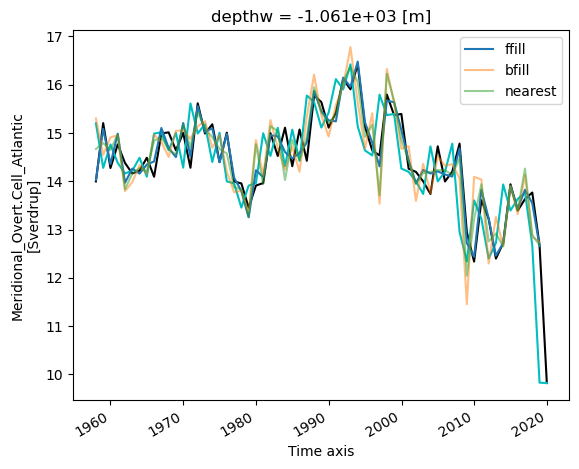

In [124]:
total_moc.resample(time_counter = '365D').mean().plot(c = 'k')
total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').ffill().resample(time_counter = '365D').mean().plot(label = 'ffill')
total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').bfill().resample(time_counter = '365D').mean().plot(label = 'bfill', alpha = .5)
total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').nearest().resample(time_counter = '365D').mean().plot(label = 'nearest', alpha = .5)

plt.legend()


rmse_bfill = root_mean_squared_error(
    total_moc.resample(time_counter = '365D').mean().values,
    total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').bfill().resample(time_counter = '365D').mean().sel(time_counter = total_moc.resample(time_counter = '365D').mean().time_counter, method = 'nearest')
)
rmse_ffill = root_mean_squared_error(
    total_moc.resample(time_counter = '365D').mean().values,
    total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').ffill().resample(time_counter = '365D').mean().sel(time_counter = total_moc.resample(time_counter = '365D').mean().time_counter, method = 'nearest')
)
rmse_nearest = root_mean_squared_error(
    total_moc.resample(time_counter = '365D').mean().values,
    total_moc.resample(time_counter = '90D').mean().resample(time_counter = '1D').nearest().resample(time_counter = '365D').mean().sel(time_counter = total_moc.resample(time_counter = '365D').mean().time_counter, method = 'nearest')
)
print(rmse_bfill, rmse_ffill, rmse_nearest)

In [19]:
total_moc.resample(time_counter = '90D').mean().resample(time_counter = '365D').apply(lambda x: x.time_counter.min())

<xarray.DataArray 'time_counter' (time_counter: 62)>
array(['1958-01-01T00:00:00.000000000', '1959-03-27T00:00:00.000000000',
       '1960-03-21T00:00:00.000000000', '1961-03-16T00:00:00.000000000',
       '1962-03-11T00:00:00.000000000', '1963-03-06T00:00:00.000000000',
       '1964-02-29T00:00:00.000000000', '1965-02-23T00:00:00.000000000',
       '1966-02-18T00:00:00.000000000', '1967-02-13T00:00:00.000000000',
       '1968-02-08T00:00:00.000000000', '1969-02-02T00:00:00.000000000',
       '1970-01-28T00:00:00.000000000', '1971-01-23T00:00:00.000000000',
       '1972-01-18T00:00:00.000000000', '1973-01-12T00:00:00.000000000',
       '1974-01-07T00:00:00.000000000', '1975-01-02T00:00:00.000000000',
       '1975-12-28T00:00:00.000000000', '1977-03-22T00:00:00.000000000',
       '1978-03-17T00:00:00.000000000', '1979-03-12T00:00:00.000000000',
       '1980-03-06T00:00:00.000000000', '1981-03-01T00:00:00.000000000',
       '1982-02-24T00:00:00.000000000', '1983-02-19T00:00:00.000000000',
       '1984-02-14T00:00:00.000000000', '1985-02-08T00:00:00.000000000',
       '1986-02-03T00:00:00.000000000', '1987-01-29T00:00:00.000000000',
       '1988-01-24T00:00:00.000000000', '1989-01-18T00:00:00.000000000',
       '1990-01-13T00:00:00.000000000', '1991-01-08T00:00:00.000000000',
       '1992-01-03T00:00:00.000000000', '1992-12-28T00:00:00.000000000',
       '1993-12-23T00:00:00.000000000', '1995-03-18T00:00:00.000000000',
       '1996-03-12T00:00:00.000000000', '1997-03-07T00:00:00.000000000',
       '1998-03-02T00:00:00.000000000', '1999-02-25T00:00:00.000000000',
       '2000-02-20T00:00:00.000000000', '2001-02-14T00:00:00.000000000',
       '2002-02-09T00:00:00.000000000', '2003-02-04T00:00:00.000000000',
       '2004-01-30T00:00:00.000000000', '2005-01-24T00:00:00.000000000',
       '2006-01-19T00:00:00.000000000', '2007-01-14T00:00:00.000000000',
       '2008-01-09T00:00:00.000000000', '2009-01-03T00:00:00.000000000',
       '2009-12-29T00:00:00.000000000', '2010-12-24T00:00:00.000000000',
       '2011-12-19T00:00:00.000000000', '2013-03-13T00:00:00.000000000',
       '2014-03-08T00:00:00.000000000', '2015-03-03T00:00:00.000000000',
       '2016-02-26T00:00:00.000000000', '2017-02-20T00:00:00.000000000',
       '2018-02-15T00:00:00.000000000', '2019-02-10T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    depthw        float32 -1.061e+03
  * time_counter  (time_counter) datetime64[ns] 1958-01-01 ... 2018-12-17

In [23]:
total_moc.resample(time_counter = '3M').apply(lambda x: x.time_counter.min())

<xarray.DataArray 'time_counter' (time_counter: 249)>
array(['1958-01-01T12:00:00.000000000', '1958-02-01T12:00:00.000000000',
       '1958-05-01T12:00:00.000000000', '1958-08-01T12:00:00.000000000',
       '1958-11-01T12:00:00.000000000', '1959-02-01T12:00:00.000000000',
       '1959-05-01T12:00:00.000000000', '1959-08-01T12:00:00.000000000',
       '1959-11-01T12:00:00.000000000', '1960-02-01T12:00:00.000000000',
       '1960-05-01T12:00:00.000000000', '1960-08-01T12:00:00.000000000',
       '1960-11-01T12:00:00.000000000', '1961-02-01T12:00:00.000000000',
       '1961-05-01T12:00:00.000000000', '1961-08-01T12:00:00.000000000',
       '1961-11-01T12:00:00.000000000', '1962-02-01T12:00:00.000000000',
       '1962-05-01T12:00:00.000000000', '1962-08-01T12:00:00.000000000',
       '1962-11-01T12:00:00.000000000', '1963-02-01T12:00:00.000000000',
       '1963-05-01T12:00:00.000000000', '1963-08-01T12:00:00.000000000',
       '1963-11-01T12:00:00.000000000', '1964-02-01T12:00:00.000000000',
       '1964-05-01T12:00:00.000000000', '1964-08-01T12:00:00.000000000',
       '1964-11-01T12:00:00.000000000', '1965-02-01T12:00:00.000000000',
       '1965-05-01T12:00:00.000000000', '1965-08-01T12:00:00.000000000',
       '1965-11-01T12:00:00.000000000', '1966-02-01T12:00:00.000000000',
       '1966-05-01T12:00:00.000000000', '1966-08-01T12:00:00.000000000',
       '1966-11-01T12:00:00.000000000', '1967-02-01T12:00:00.000000000',
       '1967-05-01T12:00:00.000000000', '1967-08-01T12:00:00.000000000',
...
       '2010-05-01T12:00:00.000000000', '2010-08-01T12:00:00.000000000',
       '2010-11-01T12:00:00.000000000', '2011-02-01T12:00:00.000000000',
       '2011-05-01T12:00:00.000000000', '2011-08-01T12:00:00.000000000',
       '2011-11-01T12:00:00.000000000', '2012-02-01T12:00:00.000000000',
       '2012-05-01T12:00:00.000000000', '2012-08-01T12:00:00.000000000',
       '2012-11-01T12:00:00.000000000', '2013-02-01T12:00:00.000000000',
       '2013-05-01T12:00:00.000000000', '2013-08-01T12:00:00.000000000',
       '2013-11-01T12:00:00.000000000', '2014-02-01T12:00:00.000000000',
       '2014-05-01T12:00:00.000000000', '2014-08-01T12:00:00.000000000',
       '2014-11-01T12:00:00.000000000', '2015-02-01T12:00:00.000000000',
       '2015-05-01T12:00:00.000000000', '2015-08-01T12:00:00.000000000',
       '2015-11-01T12:00:00.000000000', '2016-02-01T12:00:00.000000000',
       '2016-05-01T12:00:00.000000000', '2016-08-01T12:00:00.000000000',
       '2016-11-01T12:00:00.000000000', '2017-02-01T12:00:00.000000000',
       '2017-05-01T12:00:00.000000000', '2017-08-01T12:00:00.000000000',
       '2017-11-01T12:00:00.000000000', '2018-02-01T12:00:00.000000000',
       '2018-05-01T12:00:00.000000000', '2018-08-01T12:00:00.000000000',
       '2018-11-01T12:00:00.000000000', '2019-02-01T12:00:00.000000000',
       '2019-05-01T12:00:00.000000000', '2019-08-01T12:00:00.000000000',
       '2019-11-01T12:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
    depthw        float32 -1.061e+03
  * time_counter  (time_counter) datetime64[ns] 1958-01-31 ... 2020-01-31

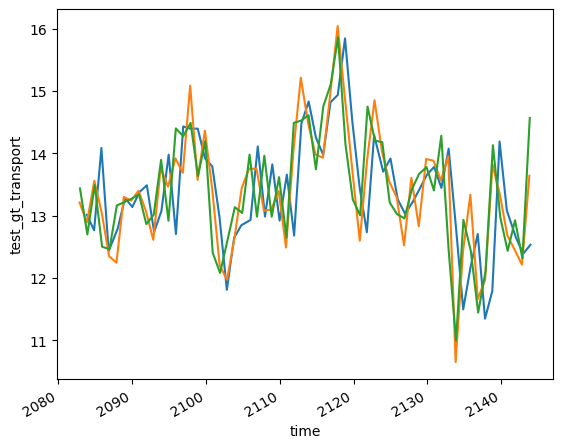

In [51]:
# test_predictions_90d.test_gt_transport.plot()
test_predictions_90d.test_gt_transport.rolling(time = 4, center = True).mean().sel(time = test_predictions_365d.time, method = 'nearest').plot()
test_predictions_90d_365d.test_gt_transport.plot()
test_predictions_365d.test_gt_transport.plot()

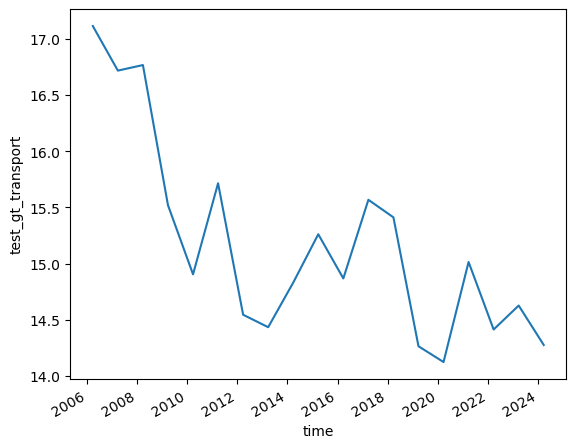

In [185]:
test_predictions_365d.test_gt_transport.interp(time = test_predictions_90d.resample(time = '1D').ffill().resample(time=f'365D').mean().time).plot()

ValueError: Input contains NaN.

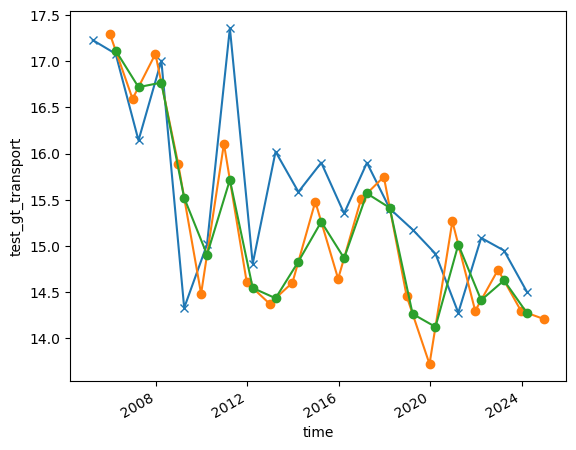

In [181]:
test_predictions_90d.resample(time = '1D').ffill().resample(time=f'365D').mean().test_predictions.plot(marker = 'x')
test_predictions_365d.test_gt_transport.plot(marker = 'o')
test_predictions_365d.test_gt_transport.interp(time = test_predictions_90d.resample(time = '1D').ffill().resample(time=f'365D').mean().time).plot(marker = 'o')

root_mean_squared_error(
    test_predictions_365d.test_gt_transport.interp(time = test_predictions_90d.resample(time = '1D').ffill().resample(time=f'365D').mean().time).values,
    test_predictions_90d.resample(time = '1D').ffill().resample(time=f'365D').mean().test_predictions.values
)

In [125]:
test_predictions_1825d.test_gt_transport.time

<xarray.DataArray 'time' (time: 11)>
array(['1681-04-01T00:25:26.290448384', '1686-03-31T00:25:26.290448384',
       '1691-03-30T00:25:26.290448384', '1696-03-28T00:25:26.290448384',
       '1701-03-28T00:25:26.290448384', '1706-03-27T00:25:26.290448384',
       '1711-03-26T00:25:26.290448384', '1716-03-24T00:25:26.290448384',
       '1721-03-23T00:25:26.290448384', '1726-03-22T00:25:26.290448384',
       '1731-03-21T00:25:26.290448384'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1681-04-01T00:25:26.290448384 ... 1731-03-...

In [130]:
test_predictions_1825d.time.max()

<xarray.DataArray 'time' ()>
array('1731-03-21T00:25:26.290448384', dtype='datetime64[ns]')

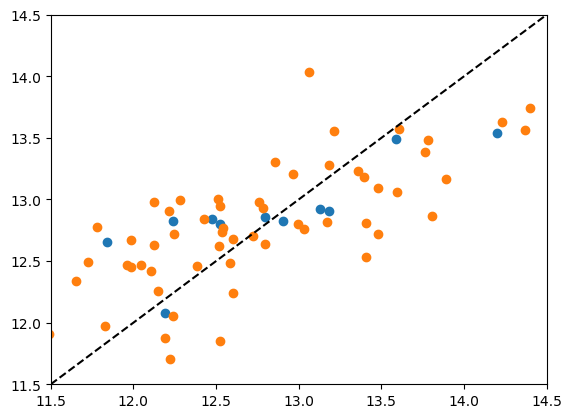

In [197]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)


ax.scatter(test_predictions_1825d.test_gt_transport, test_predictions_1825d.test_predictions, label = '1825 days')
ax.scatter(test_predictions_365d.test_gt_transport, test_predictions_365d.test_predictions, label = '1825 days')

ax.set_xlim(11.5, 14.5)
ax.set_ylim(11.5, 14.5)
ax.plot([11.5, 14.5], [11.5, 14.5], linestyle = '--', color = 'k')

In [213]:
(
    total_moc.resample(time_counter = '365D').apply(lambda x: x.time_counter.max()) - total_moc.resample(time_counter = '365D').mean().time_counter
 ) / np.timedelta64(1, 'D')


<xarray.DataArray 'time_counter' (time_counter: 63)>
array([364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,
       364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5, 364.5,  14.5])
Coordinates:
    depthw        float32 -1.061e+03
  * time_counter  (time_counter) datetime64[ns] 1958-01-01 ... 2019-12-17

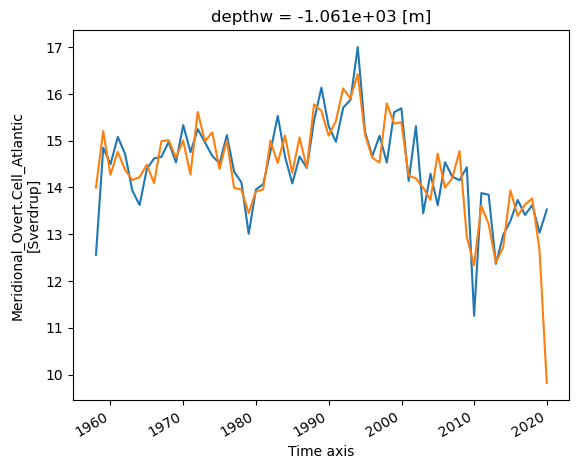

In [228]:
total_moc.groupby(total_moc.time_counter.dt.round('365D')).mean().rename({'round': 'time'}).plot()
total_moc.resample(time_counter = '365D').mean().plot()

In [221]:
total_moc.time_counter.sel(time_counter = slice('2001-01-01', '2003-01-01'))

<xarray.DataArray 'time_counter' (time_counter: 731)>
array(['2001-01-01T12:00:00.000000000', '2001-01-02T12:00:00.000000000',
       '2001-01-03T12:00:00.000000000', ..., '2002-12-30T12:00:00.000000000',
       '2002-12-31T12:00:00.000000000', '2003-01-01T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    depthw        float32 -1.061e+03
  * time_counter  (time_counter) datetime64[ns] 2001-01-01T12:00:00 ... 2003-...
Attributes:
    time_origin:  1900-01-01 00:00:00
    title:        Time
    long_name:    Time axis

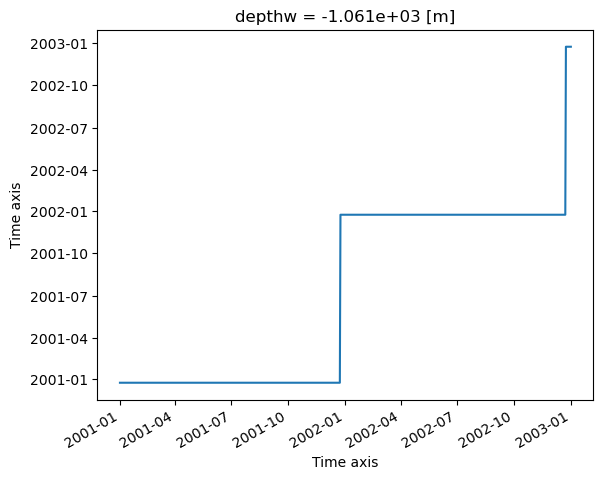

In [226]:
total_moc.time_counter.sel(time_counter = slice('2001-01-01', '2003-01-01')).dt.floor('365D').plot()